In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [21]:
df_treatment_effects = pd.read_csv('/home/kle-home-lab/code/HA-workspace/SC_Competition/HAC_Treatment Effects.csv')
df_dataset_b = pd.read_excel('/home/kle-home-lab/code/HA-workspace/SC_Competition/Dataset_B.xlsx')

print(f"Shape: {df_treatment_effects.shape}")
print(f"Columns: {df_treatment_effects.columns.tolist()}")
display(df_treatment_effects.head())

print(f"Shape: {df_dataset_b.shape}")
print(f"Columns: {df_dataset_b.columns.tolist()}")
display(df_dataset_b.head())

common_patients = set(df_treatment_effects['PAT_ID']).intersection(set(df_dataset_b['PAT_ID']))
print(f"\n{len(common_patients)} patients found in both datasets")


Shape: (100000, 6)
Columns: ['PAT_ID', 'TE1', 'TE2', 'TE3', 'TE4 (Weeks)', 'TE5 ($)']


,PAT_ID,TE1,TE2,TE3,TE4 (Weeks),TE5 ($)
0,1,0.173069,-0.206323,0.333916,6.847047,19335.35386
1,2,0.363099,-0.344177,0.294828,5.856602,24657.95630
2,3,0.389205,-0.343320,0.292875,7.002522,24660.87587
3,4,0.194947,-0.106422,0.233326,6.187393,16666.66096
4,5,0.270487,-0.136461,0.107838,4.303166,12667.00499


Shape: (1000, 6)
Columns: ['PAT_ID', 'WP1', 'WP2', 'WP3', 'WP4', 'WP5']


,PAT_ID,WP1,WP2,WP3,WP4,WP5
0,1,16.283629,3.850000,20.896097,17.296441,7.525201
1,2,42.389209,23.098464,17.059426,18.901090,24.472041
2,3,33.042328,16.867530,40.796306,6.525406,16.767300
3,4,23.225160,3.553087,10.889390,3.655582,5.185184
4,5,24.655138,22.535485,25.332269,19.957350,11.539863



1000 patients found in both datasets


In [22]:
preference_cols = ['WP1', 'WP2', 'WP3', 'WP4', 'WP5']
df_dataset_b['WP_sum'] = df_dataset_b[preference_cols].sum(axis=1)

for col in preference_cols:
    df_dataset_b[f'{col}_normalized'] = (df_dataset_b[col] / df_dataset_b['WP_sum']) * 100

print(f"\nNormalized sum check: {df_dataset_b[[f'{col}_normalized' for col in preference_cols]].sum(axis=1).describe()}")


Normalized sum check: count    1.000000e+03
mean     1.000000e+02
std      1.201397e-14
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
dtype: float64


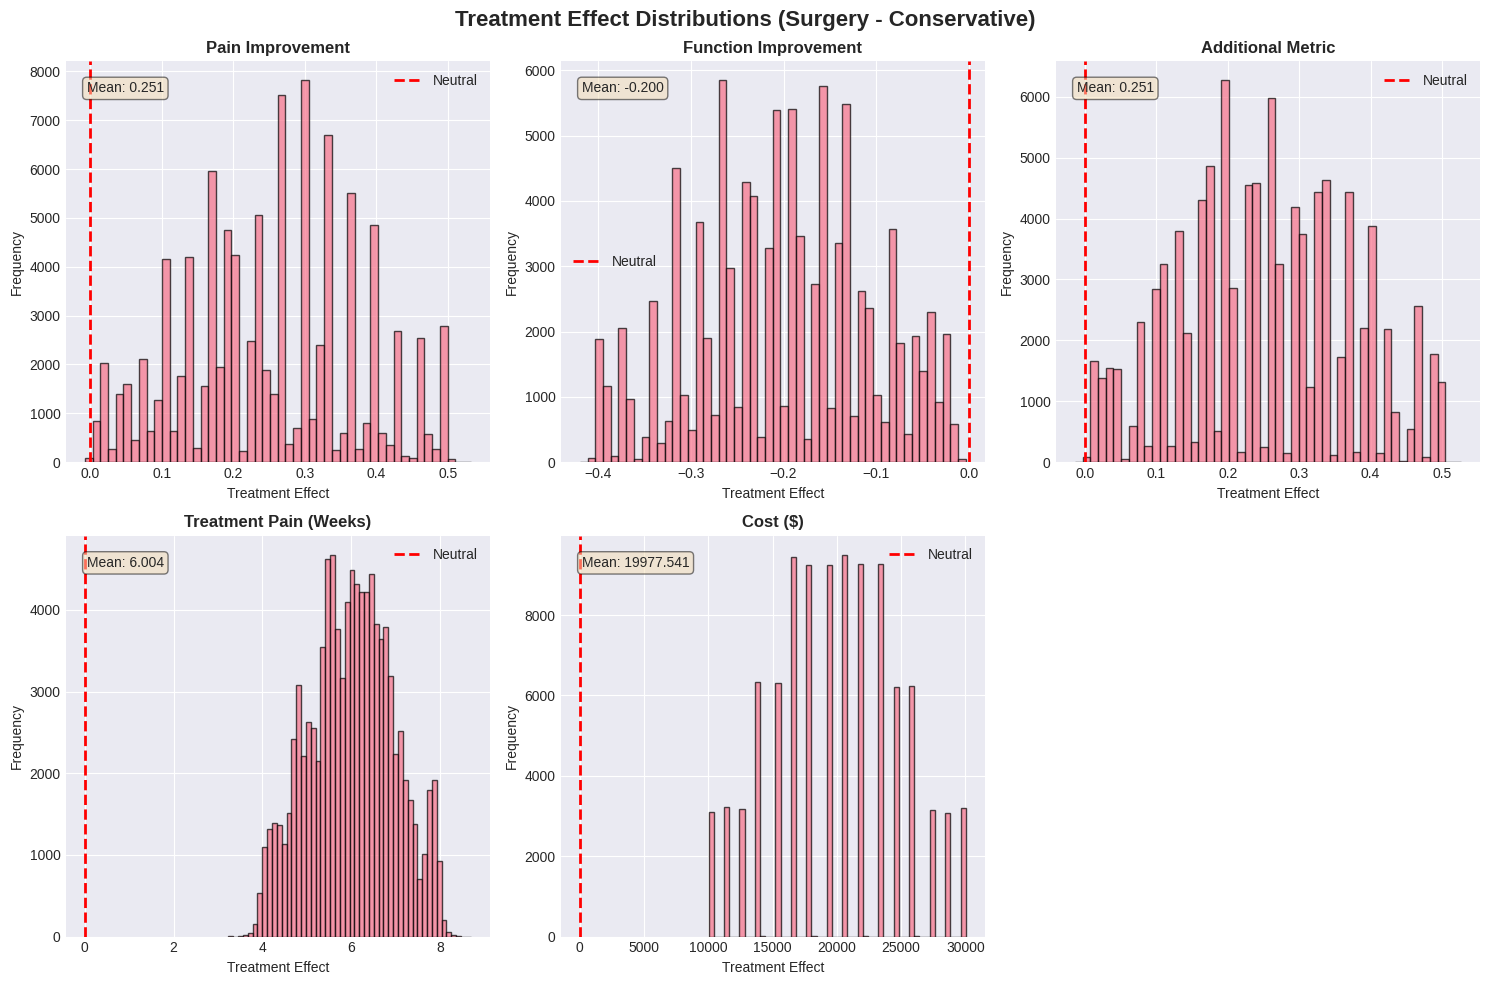

,TE1,TE2,TE3,TE4 (Weeks),TE5 ($)
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.251266,-0.199951,0.250940,6.003816,19977.541428
std,0.119759,0.094758,0.120012,0.953824,4954.795212
min,-0.007540,-0.420029,-0.014235,3.234560,10012.198540
25%,0.168748,-0.265319,0.167829,5.358309,16647.777915
50%,0.256197,-0.197776,0.243132,6.027897,19342.005425
75%,0.331738,-0.133870,0.333370,6.681778,23332.677150
max,0.532182,-0.003206,0.526298,8.697227,30022.008970


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Treatment Effect Distributions (Surgery - Conservative)', fontsize=16, fontweight='bold')

te_cols = ['TE1', 'TE2', 'TE3', 'TE4 (Weeks)', 'TE5 ($)']
te_names = ['Pain Improvement', 'Function Improvement', 'Additional Metric', 'Treatment Pain (Weeks)', 'Cost ($)']

for idx, (col, name) in enumerate(zip(te_cols, te_names)):
    ax = axes[idx // 3, idx % 3]
    df_treatment_effects[col].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Treatment Effect')
    ax.set_ylabel('Frequency')
    ax.legend()
    
    mean_val = df_treatment_effects[col].mean()
    ax.text(0.05, 0.95, f'Mean: {mean_val:.3f}', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

display(df_treatment_effects[te_cols].describe())

In [24]:
class OutcomeScaler:     
    def __init__(self):
        self.wtp_longterm_pain = 25000  
        self.wtp_treatment_pain = 15000  
        self.wtp_function = 25000  
        
    def scale_treatment_effects(self, te_row: pd.Series) -> Dict[str, float]:
        scaled = {}
        
        scaled['pain_improvement_value'] = te_row['TE1'] * self.wtp_longterm_pain
        
        scaled['function_improvement_value'] = te_row['TE2'] * self.wtp_function
        
        scaled['additional_quality_value'] = te_row['TE3'] * (self.wtp_longterm_pain + self.wtp_function) / 2
        
        scaled['treatment_pain_cost'] = -(te_row['TE4 (Weeks)'] / 52) * self.wtp_treatment_pain
        
        scaled['direct_cost'] = -te_row['TE5 ($)']
        
        return scaled
    
    def get_outcome_mapping(self) -> Dict[str, str]:
        return {
            'WP1': 'pain_improvement_value',
            'WP2': 'function_improvement_value',
            'WP3': 'treatment_pain_cost',
            'WP4': 'additional_quality_value',
            'WP5': 'direct_cost'
        }

scaler = OutcomeScaler()


print(f"  - Long-term pain elimination: ${scaler.wtp_longterm_pain:,}")
print(f"  - Treatment pain elimination: ${scaler.wtp_treatment_pain:,}")
print(f"  - Function restoration: ${scaler.wtp_function:,}")
for wp, outcome in scaler.get_outcome_mapping().items():
    print(f"  {wp} → {outcome}")

  - Long-term pain elimination: $25,000
  - Treatment pain elimination: $15,000
  - Function restoration: $25,000
  WP1 → pain_improvement_value
  WP2 → function_improvement_value
  WP3 → treatment_pain_cost
  WP4 → additional_quality_value
  WP5 → direct_cost


In [25]:
sample_te = df_treatment_effects.iloc[0]
sample_scaled = scaler.scale_treatment_effects(sample_te)

print(f"\nPatient ID: {sample_te['PAT_ID']}")
for col in ['TE1', 'TE2', 'TE3', 'TE4 (Weeks)', 'TE5 ($)']:
    print(f"  {col}: {sample_te[col]:.3f}")

for key, value in sample_scaled.items():
    print(f"  {key}: ${value:,.2f}")

print(f"\nTotal Surgery Advantage (before preferences): ${sum(sample_scaled.values()):,.2f}")


Patient ID: 1.0
  TE1: 0.173
  TE2: -0.206
  TE3: 0.334
  TE4 (Weeks): 6.847
  TE5 ($): 19335.354
  pain_improvement_value: $4,326.74
  function_improvement_value: $-5,158.09
  additional_quality_value: $8,347.89
  treatment_pain_cost: $-1,975.11
  direct_cost: $-19,335.35

Total Surgery Advantage (before preferences): $-13,793.92


In [26]:
class PreferenceIntegrator:    
    def __init__(self, scaler: OutcomeScaler):
        self.scaler = scaler
        self.outcome_mapping = scaler.get_outcome_mapping()
        
    def compute_utility(self, te_row: pd.Series, preferences: pd.Series) -> Dict:
        scaled = self.scaler.scale_treatment_effects(te_row)
        
        utility_components = {}
        total_utility = 0
        
        for wp, outcome_key in self.outcome_mapping.items():
            weight = preferences[f'{wp}_normalized'] / 100  
            outcome_value = scaled[outcome_key]
            component_utility = weight * outcome_value
            
            utility_components[outcome_key] = {
                'weight': weight,
                'outcome_value': outcome_value,
                'contribution': component_utility
            }
            total_utility += component_utility
        
        return {
            'total_utility': total_utility,
            'components': utility_components,
            'scaled_outcomes': scaled
        }

integrator = PreferenceIntegrator(scaler)

In [27]:
sample_patient_id = df_dataset_b.iloc[0]['PAT_ID']
sample_prefs = df_dataset_b.iloc[0]
sample_te = df_treatment_effects[df_treatment_effects['PAT_ID'] == sample_patient_id].iloc[0]

utility_result = integrator.compute_utility(sample_te, sample_prefs)

print(f"\nPatient ID: {sample_patient_id}")
print(f"\nPreference Weights (normalized):")
for wp in ['WP1', 'WP2', 'WP3', 'WP4', 'WP5']:
    print(f"  {wp}: {sample_prefs[f'{wp}_normalized']:.1f}%")

for outcome, details in utility_result['components'].items():
    print(f"  {outcome}:")
    print(f"    Weight: {details['weight']:.3f}")
    print(f"    Outcome Value: ${details['outcome_value']:,.2f}")
    print(f"    Contribution: ${details['contribution']:,.2f}")

print(f"Total Utility (Surgery Advantage): ${utility_result['total_utility']:,.2f}")

if utility_result['total_utility'] > 0:
    print("\n→ Surgery is recommended for this patient")
else:
    print("\n→ Conservative care is recommended for this patient")


Patient ID: 1.0

Preference Weights (normalized):
  WP1: 24.7%
  WP2: 5.8%
  WP3: 31.7%
  WP4: 26.3%
  WP5: 11.4%
  pain_improvement_value:
    Weight: 0.247
    Outcome Value: $4,326.74
    Contribution: $1,069.91
  function_improvement_value:
    Weight: 0.058
    Outcome Value: $-5,158.09
    Contribution: $-301.57
  treatment_pain_cost:
    Weight: 0.317
    Outcome Value: $-1,975.11
    Contribution: $-626.75
  additional_quality_value:
    Weight: 0.263
    Outcome Value: $8,347.89
    Contribution: $2,192.65
  direct_cost:
    Weight: 0.114
    Outcome Value: $-19,335.35
    Contribution: $-2,209.56
Total Utility (Surgery Advantage): $124.68

→ Surgery is recommended for this patient


In [28]:
class TreatmentRecommender:
    def __init__(self, integrator: PreferenceIntegrator, 
                 borderline_threshold: float = 2000):
        self.integrator = integrator
        self.borderline_threshold = borderline_threshold
        
    def recommend(self, te_row: pd.Series, preferences: pd.Series) -> Dict:
        utility_result = self.integrator.compute_utility(te_row, preferences)
        total_utility = utility_result['total_utility']

        if total_utility > 0:
            recommended_treatment = 'Surgery'
        else:
            recommended_treatment = 'Conservative'

        abs_utility = abs(total_utility)
        
        if abs_utility < self.borderline_threshold:
            confidence = 'Low - Borderline'
            borderline = True
        elif abs_utility < self.borderline_threshold * 2:
            confidence = 'Moderate'
            borderline = False
        else:
            confidence = 'High'
            borderline = False
        

        trade_offs = self._identify_tradeoffs(utility_result['scaled_outcomes'])
        
        qualifications = self._generate_qualifications(
            utility_result, borderline, recommended_treatment
        )
        
        return {
            'patient_id': te_row['PAT_ID'],
            'recommended_treatment': recommended_treatment,
            'confidence': confidence,
            'borderline': borderline,
            'utility_difference': total_utility,
            'utility_details': utility_result,
            'trade_offs': trade_offs,
            'qualifications': qualifications
        }
    
    def _identify_tradeoffs(self, scaled_outcomes: Dict) -> List[str]:
        trade_offs = []
        
        for outcome, value in scaled_outcomes.items():
            if value > 500:  
                trade_offs.append(f"Surgery shows ${value:,.0f} advantage in {outcome.replace('_', ' ')}")
            elif value < -500: 
                trade_offs.append(f"Conservative care shows ${-value:,.0f} advantage in {outcome.replace('_', ' ')}")
        
        return trade_offs
    
    def _generate_qualifications(self, utility_result: Dict, 
                                   borderline: bool, 
                                   recommended: str) -> List[str]:
        qualifications = []
        
        if borderline:
            qualifications.append(
                "BORDERLINE CASE: Both treatments show similar overall benefit. "
                "Strong emphasis on patient values and shared decision-making."
            )
        
        components = utility_result['components']
        positive_components = [k for k, v in components.items() if v['contribution'] > 0]
        negative_components = [k for k, v in components.items() if v['contribution'] < 0]
        
        if len(positive_components) > 0 and len(negative_components) > 0:
            qualifications.append(
                f"Mixed outcomes: {recommended} is better in some areas but worse in others. "
                "Discuss specific trade-offs with patient."
            )
        
        cost_contribution = components['direct_cost']['contribution']
        if abs(cost_contribution) > abs(utility_result['total_utility']) * 0.5:
            qualifications.append(
                "Cost is a major factor in this recommendation. "
                "Consider patient's financial situation and insurance coverage."
            )
        
        return qualifications


recommender = TreatmentRecommender(integrator, borderline_threshold=2000)

print(f"  Borderline threshold: ${recommender.borderline_threshold:,}")

  Borderline threshold: $2,000


In [29]:
recommendation = recommender.recommend(sample_te, sample_prefs)

print("CLINICAL DECISION SUPPORT RECOMMENDATION")
print("=" * 70)
print(f"\nPatient ID: {recommendation['patient_id']}")
print(f"\nRECOMMENDED TREATMENT: {recommendation['recommended_treatment']}")
print(f"Confidence Level: {recommendation['confidence']}")
print(f"Utility Difference: ${recommendation['utility_difference']:,.2f}")

print("KEY TRADE-OFFS")
print("=" * 70)
if recommendation['trade_offs']:
    for i, trade_off in enumerate(recommendation['trade_offs'], 1):
        print(f"{i}. {trade_off}")
else:
    print("No significant trade-offs identified.")

print("CLINICAL QUALIFICATIONS FOR SDM")
print("=" * 70)
if recommendation['qualifications']:
    for i, qual in enumerate(recommendation['qualifications'], 1):
        print(f"{i}. {qual}")
else:
    print("Clear recommendation with no special qualifications.")

CLINICAL DECISION SUPPORT RECOMMENDATION

Patient ID: 1.0

RECOMMENDED TREATMENT: Surgery
Confidence Level: Low - Borderline
Utility Difference: $124.68
KEY TRADE-OFFS
1. Surgery shows $4,327 advantage in pain improvement value
2. Conservative care shows $5,158 advantage in function improvement value
3. Surgery shows $8,348 advantage in additional quality value
4. Conservative care shows $1,975 advantage in treatment pain cost
5. Conservative care shows $19,335 advantage in direct cost
CLINICAL QUALIFICATIONS FOR SDM
1. BORDERLINE CASE: Both treatments show similar overall benefit. Strong emphasis on patient values and shared decision-making.
2. Mixed outcomes: Surgery is better in some areas but worse in others. Discuss specific trade-offs with patient.
3. Cost is a major factor in this recommendation. Consider patient's financial situation and insurance coverage.


In [30]:
df_merged = df_dataset_b.merge(
    df_treatment_effects, 
    on='PAT_ID', 
    how='inner'
)

print(f"Merged data shape: {df_merged.shape}")
print(f"\nProcessing {len(df_merged)} patients...")

recommendations_list = []

for idx, row in df_merged.iterrows():
    recommendation = recommender.recommend(row, row)
    
    recommendations_list.append({
        'PAT_ID': row['PAT_ID'],
        'Predicted_Treatment': recommendation['recommended_treatment'],
        'Confidence': recommendation['confidence'],
        'Utility_Difference': recommendation['utility_difference'],
        'Borderline': recommendation['borderline'],
        'Num_Trade_Offs': len(recommendation['trade_offs']),
        'Num_Qualifications': len(recommendation['qualifications'])
    })
    
    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx + 1} patients...")

df_recommendations = pd.DataFrame(recommendations_list)

print(f"\nSuccessfully processed {len(df_recommendations)} patients")
display(df_recommendations.head(10))

Merged data shape: (1000, 17)

Processing 1000 patients...
  Processed 100 patients...
  Processed 200 patients...
  Processed 300 patients...
  Processed 400 patients...
  Processed 500 patients...
  Processed 600 patients...
  Processed 700 patients...
  Processed 800 patients...
  Processed 900 patients...
  Processed 1000 patients...

Successfully processed 1000 patients


,PAT_ID,Predicted_Treatment,Confidence,Utility_Difference,Borderline,Num_Trade_Offs,Num_Qualifications
0,1.0,Surgery,Low - Borderline,124.684618,True,5,3
1,2.0,Conservative,Moderate,-2437.241165,False,5,2
2,3.0,Conservative,Moderate,-2380.666445,False,5,2
3,4.0,Surgery,Low - Borderline,412.971040,True,5,3
4,5.0,Conservative,Low - Borderline,-326.614378,True,5,3
5,6.0,Surgery,Low - Borderline,220.672395,True,5,3
6,7.0,Surgery,Moderate,2290.428008,False,5,1
7,8.0,Conservative,High,-4373.368778,False,4,2
8,9.0,Conservative,Low - Borderline,-247.220997,True,5,3
9,10.0,Conservative,Low - Borderline,-1803.037842,True,5,3


In [31]:
print("\nTreatment Distribution:")
print(df_recommendations['Predicted_Treatment'].value_counts())
print(f"\nPercentage Surgery: {(df_recommendations['Predicted_Treatment'] == 'Surgery').mean() * 100:.1f}%")
print(f"Percentage Conservative: {(df_recommendations['Predicted_Treatment'] == 'Conservative').mean() * 100:.1f}%")

print("\nConfidence Distribution:")
print(df_recommendations['Confidence'].value_counts())

print("\nBorderline Cases:")
print(f"Total borderline: {df_recommendations['Borderline'].sum()} ({df_recommendations['Borderline'].mean() * 100:.1f}%)")

print("\nUtility Difference Statistics:")
print(df_recommendations['Utility_Difference'].describe())


Treatment Distribution:
Predicted_Treatment
Conservative    723
Surgery         277
Name: count, dtype: int64

Percentage Surgery: 27.7%
Percentage Conservative: 72.3%

Confidence Distribution:
Confidence
Low - Borderline    662
Moderate            288
High                 50
Name: count, dtype: int64

Borderline Cases:
Total borderline: 662 (66.2%)

Utility Difference Statistics:
count    1000.000000
mean    -1103.981064
std      1797.868766
min     -8185.748916
25%     -2253.087312
50%     -1080.305762
75%       146.136429
max      5225.176460
Name: Utility_Difference, dtype: float64


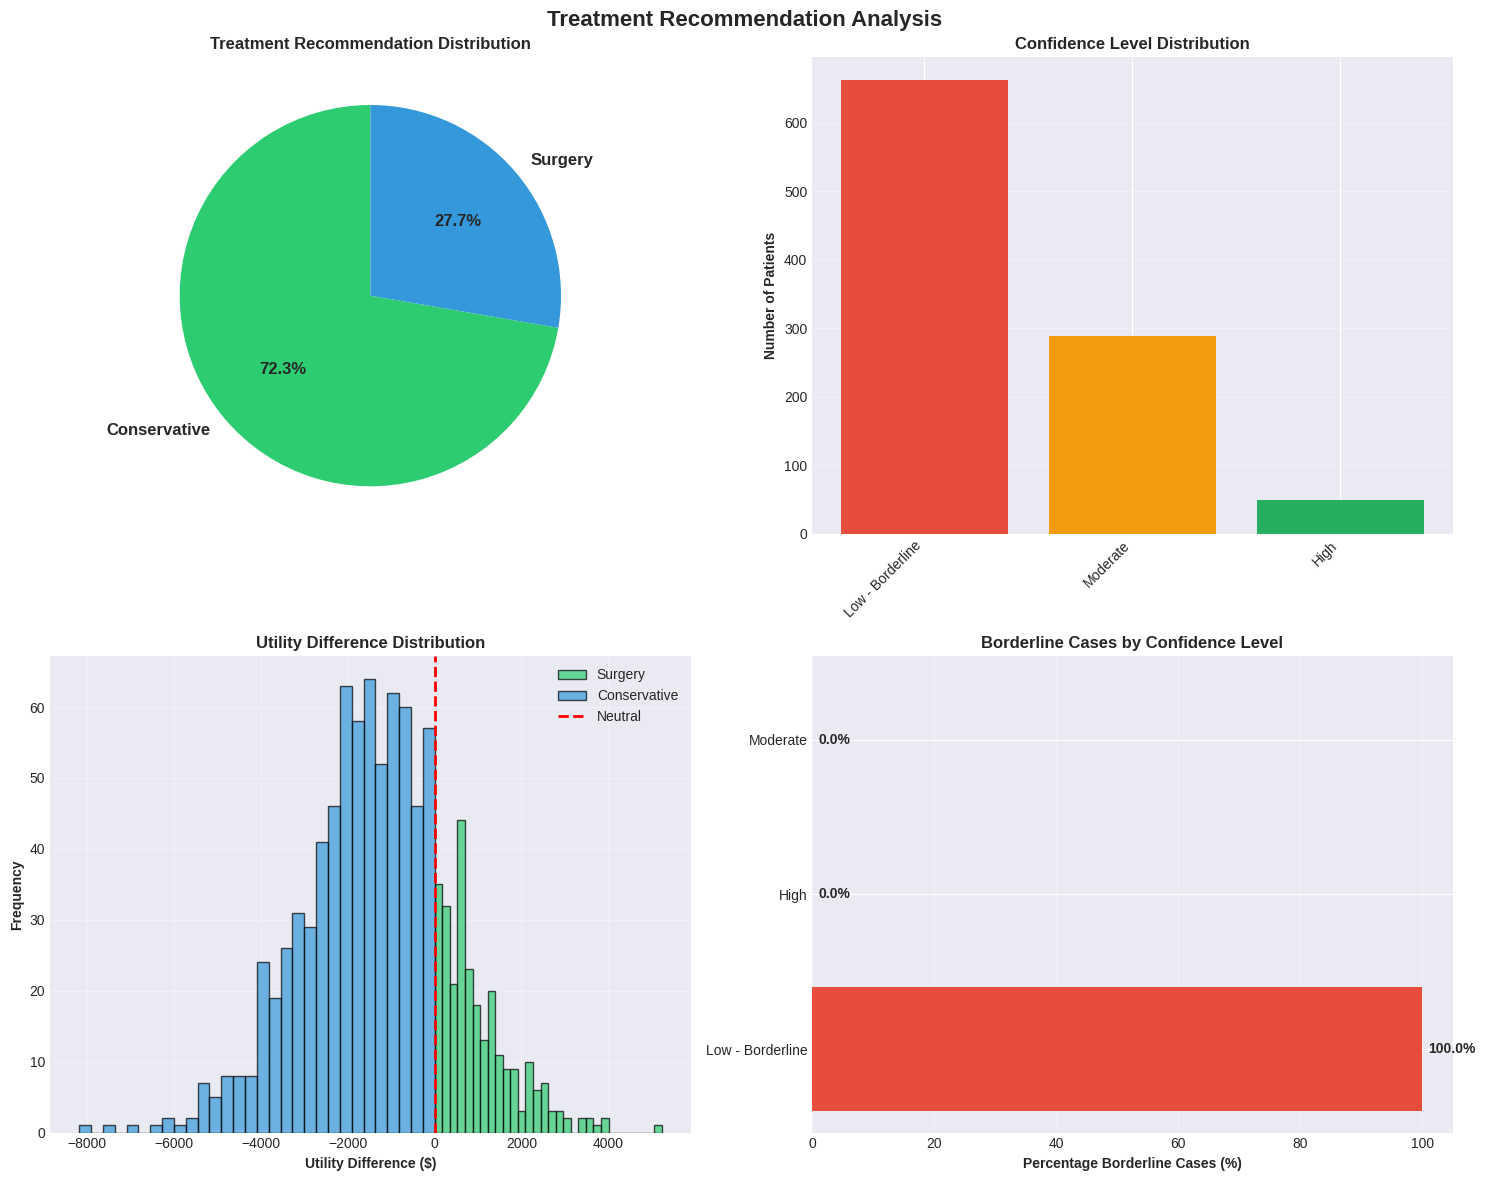

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Treatment Recommendation Analysis', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
treatment_counts = df_recommendations['Predicted_Treatment'].value_counts()
colors = ['#2ecc71', '#3498db']
ax1.pie(treatment_counts.values, labels=treatment_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, textprops={'fontsize': 12, 'weight': 'bold'})
ax1.set_title('Treatment Recommendation Distribution', fontweight='bold')

ax2 = axes[0, 1]
confidence_counts = df_recommendations['Confidence'].value_counts()
ax2.bar(range(len(confidence_counts)), confidence_counts.values, 
        color=['#e74c3c', '#f39c12', '#27ae60'])
ax2.set_xticks(range(len(confidence_counts)))
ax2.set_xticklabels(confidence_counts.index, rotation=45, ha='right')
ax2.set_ylabel('Number of Patients', fontweight='bold')
ax2.set_title('Confidence Level Distribution', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[1, 0]
surgery_utils = df_recommendations[df_recommendations['Predicted_Treatment'] == 'Surgery']['Utility_Difference']
conservative_utils = df_recommendations[df_recommendations['Predicted_Treatment'] == 'Conservative']['Utility_Difference']

ax3.hist(surgery_utils, bins=30, alpha=0.7, label='Surgery', color='#2ecc71', edgecolor='black')
ax3.hist(conservative_utils, bins=30, alpha=0.7, label='Conservative', color='#3498db', edgecolor='black')
ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral')
ax3.set_xlabel('Utility Difference ($)', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('Utility Difference Distribution', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

ax4 = axes[1, 1]
borderline_by_conf = df_recommendations.groupby('Confidence')['Borderline'].sum()
total_by_conf = df_recommendations.groupby('Confidence').size()
borderline_pct = (borderline_by_conf / total_by_conf * 100).sort_values(ascending=False)

ax4.barh(range(len(borderline_pct)), borderline_pct.values, color='#e74c3c')
ax4.set_yticks(range(len(borderline_pct)))
ax4.set_yticklabels(borderline_pct.index)
ax4.set_xlabel('Percentage Borderline Cases (%)', fontweight='bold')
ax4.set_title('Borderline Cases by Confidence Level', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

for i, v in enumerate(borderline_pct.values):
    ax4.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [33]:
class SensitivityAnalyzer:
    def __init__(self, recommender: TreatmentRecommender):
        self.recommender = recommender
        
    def analyze_preference_sensitivity(self, te_row: pd.Series, 
                                        base_preferences: pd.Series,
                                        variation_pct: float = 20) -> Dict:
        base_rec = self.recommender.recommend(te_row, base_preferences)
        base_treatment = base_rec['recommended_treatment']
        
        sensitivity_results = {
            'base_recommendation': base_treatment,
            'base_utility': base_rec['utility_difference'],
            'variations': {},
            'recommendation_stable': True
        }
        
        preference_cols = ['WP1', 'WP2', 'WP3', 'WP4', 'WP5']
        
        for wp in preference_cols:
            varied_prefs = base_preferences.copy()
            for col in preference_cols:
                norm_col = f'{col}_normalized'
                if col == wp:
                    varied_prefs[norm_col] = base_preferences[norm_col] * (1 + variation_pct/100)
                else:
                    varied_prefs[norm_col] = base_preferences[norm_col] * (1 - variation_pct/(100 * (len(preference_cols) - 1)))
            
            total = sum([varied_prefs[f'{col}_normalized'] for col in preference_cols])
            for col in preference_cols:
                varied_prefs[f'{col}_normalized'] = (varied_prefs[f'{col}_normalized'] / total) * 100
            
            new_rec = self.recommender.recommend(te_row, varied_prefs)
            new_treatment = new_rec['recommended_treatment']
            
            sensitivity_results['variations'][f'{wp}_increase'] = {
                'new_recommendation': new_treatment,
                'new_utility': new_rec['utility_difference'],
                'changed': new_treatment != base_treatment
            }
            
            if new_treatment != base_treatment:
                sensitivity_results['recommendation_stable'] = False
            
            margin = abs(sensitivity_results['base_utility'])
            if margin < 2000:
                sensitivity_results['sensitivity_level'] = 'High'
            elif margin < 4000:
                sensitivity_results['sensitivity_level'] = 'Moderate'
            else:
                sensitivity_results['sensitivity_level'] = 'Low'
        
        return sensitivity_results

sensitivity_analyzer = SensitivityAnalyzer(recommender)


In [34]:
sensitivity_result = sensitivity_analyzer.analyze_preference_sensitivity(
    sample_te, sample_prefs, variation_pct=20
)

print(f"\nBase Recommendation: {sensitivity_result['base_recommendation']}")
print(f"Base Utility: ${sensitivity_result['base_utility']:,.2f}")
print(f"\nRecommendation Stability: {'STABLE' if sensitivity_result['recommendation_stable'] else 'UNSTABLE'}")
print(f"Sensitivity Level: {sensitivity_result.get('sensitivity_level', 'N/A')}")

for wp, result in sensitivity_result['variations'].items():
    status = "CHANGED" if result['changed'] else "SAME"
    print(f"{wp:20s}: {result['new_recommendation']:12s} (${result['new_utility']:>10,.2f}) {status}")

if not sensitivity_result['recommendation_stable']:
    print("\n WARNING: Recommendation is sensitive to preference changes.")
    print("Consider this a borderline case requiring careful SDM.")


Base Recommendation: Surgery
Base Utility: $124.68

Recommendation Stability: UNSTABLE
Sensitivity Level: High
WP1_increase        : Surgery      ($    381.42) SAME
WP2_increase        : Surgery      ($     44.64) SAME
WP3_increase        : Conservative ($    -37.15) CHANGED
WP4_increase        : Surgery      ($    656.33) SAME
WP5_increase        : Conservative ($   -443.44) CHANGED

Consider this a borderline case requiring careful SDM.


In [35]:
# Create final submission file
df_submission = df_recommendations[['PAT_ID', 'Predicted_Treatment']].copy()

print(f"\nTotal patients: {len(df_submission)}")
print(f"\nTreatment distribution:")
print(df_submission['Predicted_Treatment'].value_counts())

display(df_submission.head(20))


Total patients: 1000

Treatment distribution:
Predicted_Treatment
Conservative    723
Surgery         277
Name: count, dtype: int64


,PAT_ID,Predicted_Treatment
0,1.0,Surgery
1,2.0,Conservative
2,3.0,Conservative
3,4.0,Surgery
4,5.0,Conservative
5,6.0,Surgery
6,7.0,Surgery
7,8.0,Conservative
8,9.0,Conservative
9,10.0,Conservative


In [36]:
output_path = '/home/kle-home-lab/code/HA-workspace/SC_Competition/Dataset_B_Predictions.xlsx'
df_submission.to_excel(output_path, index=False)

print(f"Predictions saved to: {output_path}")
print(f"  Columns: {df_submission.columns.tolist()}")
print(f"  Rows: {len(df_submission)}")

Predictions saved to: /home/kle-home-lab/code/HA-workspace/SC_Competition/Dataset_B_Predictions.xlsx
  Columns: ['PAT_ID', 'Predicted_Treatment']
  Rows: 1000


In [37]:
df_detailed_report = df_recommendations.copy()

for wp in ['WP1', 'WP2', 'WP3', 'WP4', 'WP5']:
    df_detailed_report[wp] = df_merged[f'{wp}_normalized']

for te in ['TE1', 'TE2', 'TE3', 'TE4 (Weeks)', 'TE5 ($)']:
    df_detailed_report[te] = df_merged[te]

column_order = ['PAT_ID', 'Predicted_Treatment', 'Confidence', 'Utility_Difference', 'Borderline',
                'WP1', 'WP2', 'WP3', 'WP4', 'WP5',
                'TE1', 'TE2', 'TE3', 'TE4 (Weeks)', 'TE5 ($)',
                'Num_Trade_Offs', 'Num_Qualifications']

df_detailed_report = df_detailed_report[column_order]

detailed_output_path = '/home/kle-home-lab/code/HA-workspace/SC_Competition/Dataset_B_Detailed_Report.xlsx'
df_detailed_report.to_excel(detailed_output_path, index=False)

print(f"Detailed report saved to: {detailed_output_path}")
print(f"  Total columns: {len(df_detailed_report.columns)}")
print(f"  Includes: Predictions, Confidence, Utility, Preferences, and Treatment Effects")

print("\nSample from detailed report:")
display(df_detailed_report.head())

Detailed report saved to: /home/kle-home-lab/code/HA-workspace/SC_Competition/Dataset_B_Detailed_Report.xlsx
  Total columns: 17
  Includes: Predictions, Confidence, Utility, Preferences, and Treatment Effects

Sample from detailed report:


,PAT_ID,Predicted_Treatment,Confidence,Utility_Difference,Borderline,WP1,WP2,WP3,WP4,WP5,TE1,TE2,TE3,TE4 (Weeks),TE5 ($),Num_Trade_Offs,Num_Qualifications
0,1.0,Surgery,Low - Borderline,124.684618,True,24.727853,5.846500,31.732214,26.265879,11.427554,0.173069,-0.206323,0.333916,6.847047,19335.35386,5,3
1,2.0,Conservative,Moderate,-2437.241165,False,33.663542,18.343728,13.547804,15.010368,19.434559,0.363099,-0.344177,0.294828,5.856602,24657.95630,5,2
2,3.0,Conservative,Moderate,-2380.666445,False,28.984785,14.796226,35.786588,5.724097,14.708304,0.389205,-0.343320,0.292875,7.002522,24660.87587,5,2
3,4.0,Surgery,Low - Borderline,412.971040,True,49.937557,7.639667,23.413811,7.860045,11.148919,0.194947,-0.106422,0.233326,6.187393,16666.66096,5,3
4,5.0,Conservative,Low - Borderline,-326.614378,True,23.702282,21.664547,24.353243,19.186051,11.093877,0.270487,-0.136461,0.107838,4.303166,12667.00499,5,3


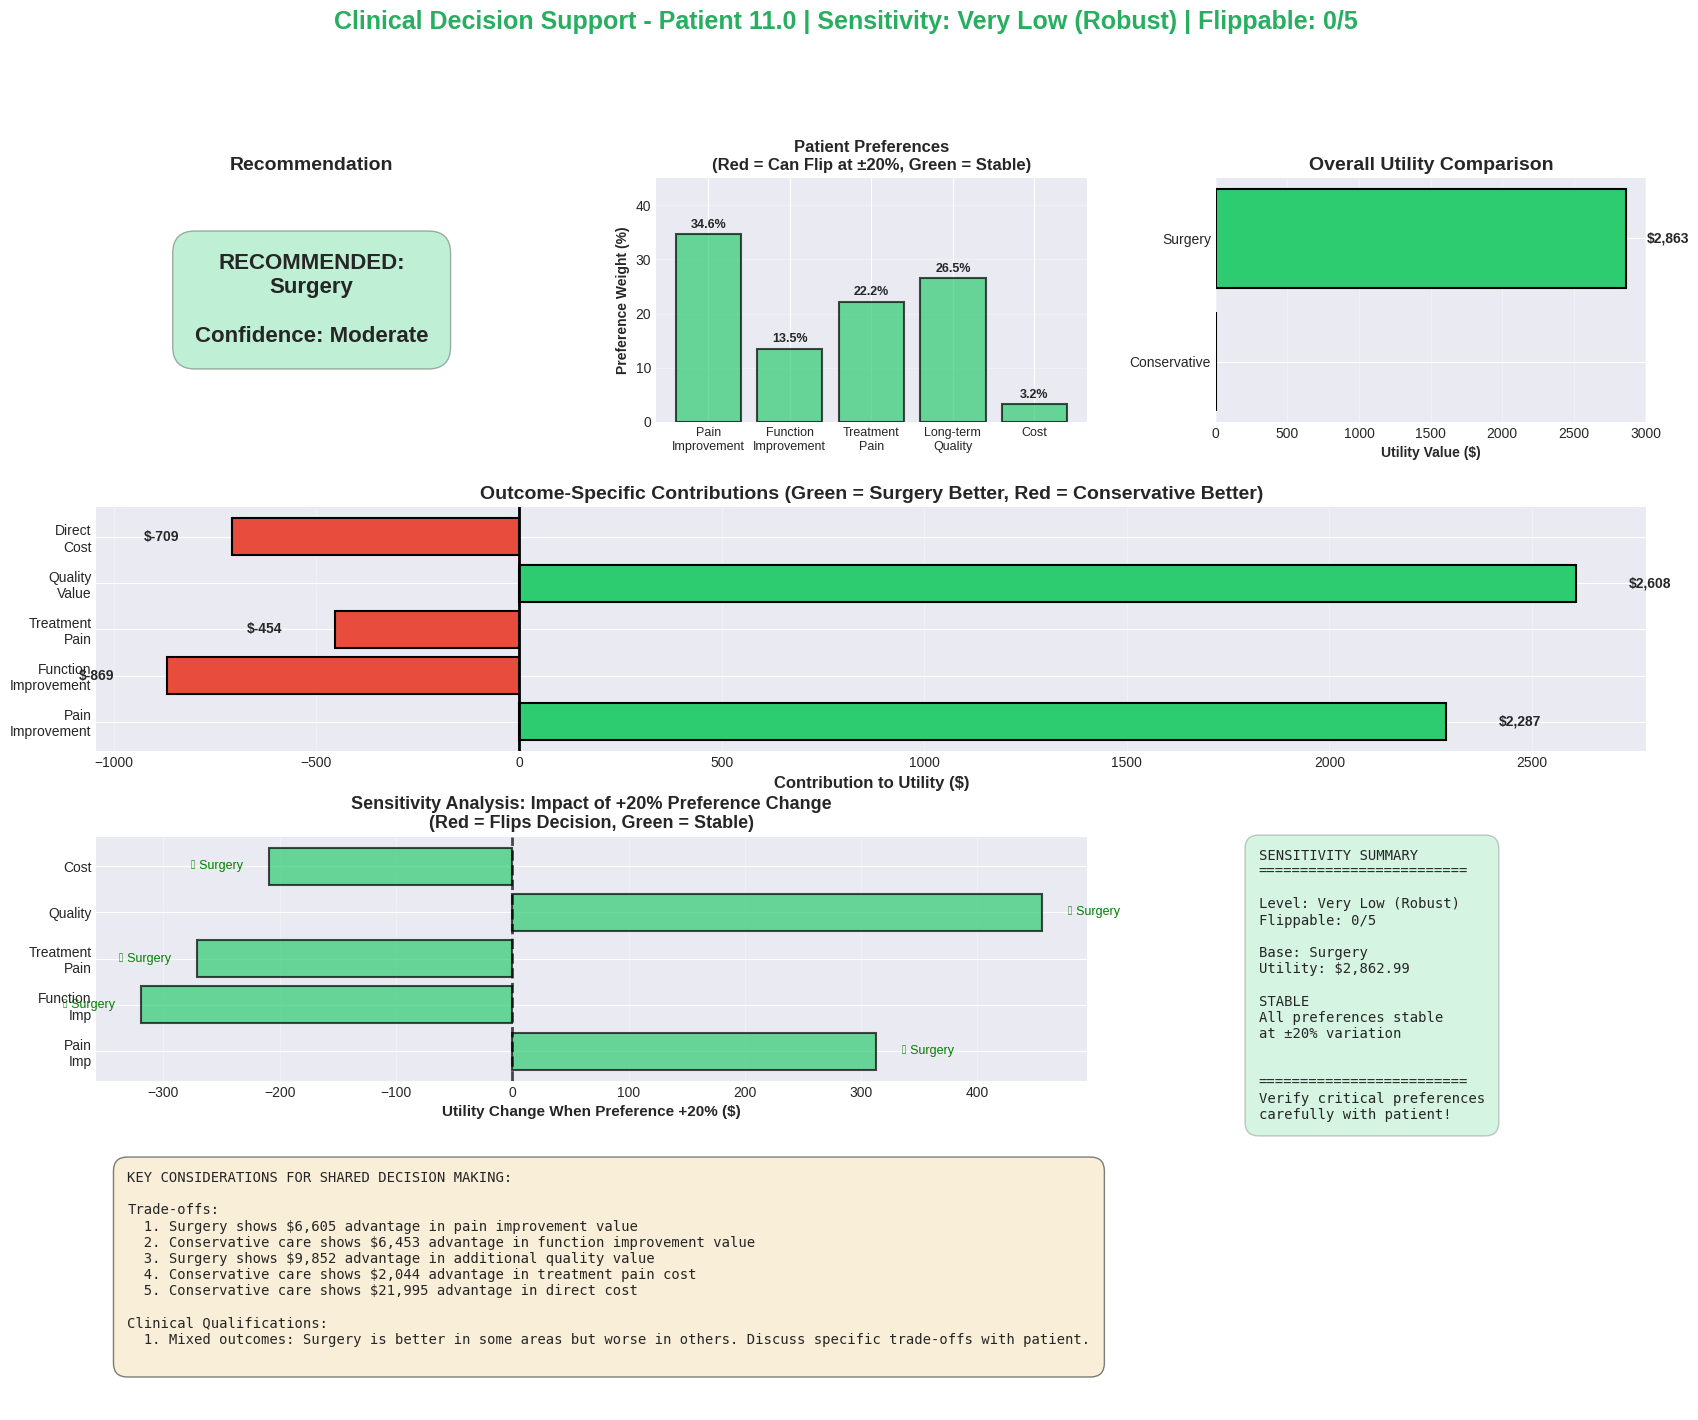

In [38]:
from operator import le


def create_cds_visualization(patient_id: int, 
                             recommender,
                             sensitivity_analyzer,
                             df_te: pd.DataFrame, 
                             df_prefs: pd.DataFrame):

    te_row = df_te[df_te['PAT_ID'] == patient_id].iloc[0]
    pref_row = df_prefs[df_prefs['PAT_ID'] == patient_id].iloc[0]

    rec = recommender.recommend(te_row, pref_row)

    sensitivity_result = sensitivity_analyzer.analyze_preference_sensitivity(
        te_row, pref_row, variation_pct=20
    )
    

    num_flippable = sum([result['changed'] for result in sensitivity_result['variations'].values()])
    base_utility = sensitivity_result['base_utility']
    abs_utility = abs(base_utility)

    if num_flippable == 0:
        sensitivity_level = "Very Low (Robust)"
    elif num_flippable == 1 and abs_utility > 2000:
        sensitivity_level = "Low (Stable)"
    elif num_flippable == 1 and abs_utility <= 2000:
        sensitivity_level = "Moderate"
    elif num_flippable == 2 and abs_utility > 1000:
        sensitivity_level = "Moderate-High"
    elif num_flippable == 2 and abs_utility <= 1000:
        sensitivity_level = "High"
    elif num_flippable >= 3 and abs_utility > 500:
        sensitivity_level = "High (Fragile)"
    else:  # num_flippable >= 3 and abs_utility <= 500
        sensitivity_level = "Very High (Critical)"
    
    sensitivity_result['sensitivity_level'] = sensitivity_level
    sensitivity_result['num_flippable'] = num_flippable
    
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)
    
    sensitivity_colors = {
        "Very Low (Robust)": '#27ae60',
        "Low (Stable)": '#2ecc71',
        "Moderate": '#f39c12',
        "Moderate-High": '#e67e22',
        "High": '#e74c3c',
        "High (Fragile)": '#c0392b',
        "Very High (Critical)": '#8b0000'
    }
    
    title_color = sensitivity_colors.get(sensitivity_level, '#000000')
    
    fig.suptitle(
        f'Clinical Decision Support - Patient {patient_id} | '
        f'Sensitivity: {sensitivity_level} | Flippable: {num_flippable}/5', 
        fontsize=18, fontweight='bold', y=0.985, color=title_color
    )
    
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.axis('off')
    rec_text = f"RECOMMENDED:\n{rec['recommended_treatment']}\n\nConfidence: {rec['confidence']}"
    rec_color = '#2ecc71' if rec['recommended_treatment'] == 'Surgery' else '#3498db'
    ax1.text(0.5, 0.5, rec_text, ha='center', va='center',
             fontsize=16, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor=rec_color, alpha=0.3, pad=1))
    ax1.set_title('Recommendation', fontweight='bold', fontsize=14)
    
    ax2 = fig.add_subplot(gs[0, 1])
    pref_labels = ['Pain\nImprovement', 'Function\nImprovement', 'Treatment\nPain', 
                   'Long-term\nQuality', 'Cost']
    pref_values = [pref_row[f'WP{i}_normalized'] for i in range(1, 6)]
    
    pref_codes = ['WP1', 'WP2', 'WP3', 'WP4', 'WP5']
    colors_pref = []
    for i, wp in enumerate(pref_codes, 1):
        variation_key_increase = f'WP{i}_increase'
        if variation_key_increase in sensitivity_result['variations']:
            if sensitivity_result['variations'][variation_key_increase]['changed']:
                colors_pref.append('#e74c3c')  
            else:
                colors_pref.append('#2ecc71')  
        else:
            colors_pref.append(plt.cm.Set3(i-1))  
    
    bars = ax2.bar(range(5), pref_values, color=colors_pref, 
                   edgecolor='black', linewidth=1.5, alpha=0.7)
    ax2.set_xticks(range(5))
    ax2.set_xticklabels(pref_labels, fontsize=9)
    ax2.set_ylabel('Preference Weight (%)', fontweight='bold')
    ax2.set_title('Patient Preferences\n(Red = Can Flip at ±20%, Green = Stable)', 
                  fontweight='bold', fontsize=12)
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_ylim(0, max(pref_values) * 1.3)
    
    for i, (bar, val) in enumerate(zip(bars, pref_values)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + max(pref_values)*0.02,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax3 = fig.add_subplot(gs[0, 2])
    utility_val = rec['utility_difference']
    surgery_util = max(0, utility_val)
    conservative_util = max(0, -utility_val)
    
    bars = ax3.barh(['Conservative', 'Surgery'], 
                    [conservative_util, surgery_util],
                    color=['#3498db', '#2ecc71'], edgecolor='black', linewidth=1.5)
    ax3.set_xlabel('Utility Value ($)', fontweight='bold')
    ax3.set_title('Overall Utility Comparison', fontweight='bold', fontsize=14)
    ax3.grid(axis='x', alpha=0.3)
    
    for i, bar in enumerate(bars):
        width = bar.get_width()
        if width > 0:
            ax3.text(width + max(surgery_util, conservative_util)*0.05, 
                    bar.get_y() + bar.get_height()/2, 
                    f'${width:,.0f}', ha='left', va='center', fontweight='bold')
    
    ax4 = fig.add_subplot(gs[1, :])
    
    outcome_names = ['Pain\nImprovement', 'Function\nImprovement', 'Treatment\nPain',
                     'Quality\nValue', 'Direct\nCost']
    outcome_values = [
        rec['utility_details']['components']['pain_improvement_value']['contribution'],
        rec['utility_details']['components']['function_improvement_value']['contribution'],
        rec['utility_details']['components']['treatment_pain_cost']['contribution'],
        rec['utility_details']['components']['additional_quality_value']['contribution'],
        rec['utility_details']['components']['direct_cost']['contribution']
    ]
    
    colors_outcomes = ['#2ecc71' if v > 0 else '#e74c3c' for v in outcome_values]
    bars = ax4.barh(range(5), outcome_values, color=colors_outcomes, 
                    edgecolor='black', linewidth=1.5)
    ax4.set_yticks(range(5))
    ax4.set_yticklabels(outcome_names)
    ax4.set_xlabel('Contribution to Utility ($)', fontweight='bold', fontsize=12)
    ax4.set_title('Outcome-Specific Contributions (Green = Surgery Better, Red = Conservative Better)', 
                  fontweight='bold', fontsize=14)
    ax4.axvline(0, color='black', linewidth=2)
    ax4.grid(axis='x', alpha=0.3)
    
    for i, (bar, val) in enumerate(zip(bars, outcome_values)):
        width = bar.get_width()
        max_abs = max(abs(min(outcome_values)), abs(max(outcome_values)))
        label_x = width + (max_abs * 0.05 * (1 if width > 0 else -1))
        ax4.text(label_x, bar.get_y() + bar.get_height()/2, 
                f'${val:,.0f}', ha='left' if width > 0 else 'right', 
                va='center', fontweight='bold', fontsize=10)
    

    ax5 = fig.add_subplot(gs[2, :2])
    
    pref_names_short = ['Pain\nImp', 'Function\nImp', 'Treatment\nPain', 'Quality', 'Cost']
    base_util = sensitivity_result['base_utility']
    
    new_utilities = []
    changed_flags = []
    for i in range(1, 6):
        var_key = f'WP{i}_increase'
        if var_key in sensitivity_result['variations']:
            new_util = sensitivity_result['variations'][var_key]['new_utility']
            changed = sensitivity_result['variations'][var_key]['changed']
            new_utilities.append(new_util)
            changed_flags.append(changed)
        else:
            new_utilities.append(base_util)
            changed_flags.append(False)
    
    utility_changes = [new_util - base_util for new_util in new_utilities]
    
    colors_sensitivity = ['#e74c3c' if changed else '#2ecc71' 
                         for changed in changed_flags]
    
    bars = ax5.barh(range(5), utility_changes, color=colors_sensitivity,
                    edgecolor='black', linewidth=1.5, alpha=0.7)
    ax5.set_yticks(range(5))
    ax5.set_yticklabels(pref_names_short, fontsize=10)
    ax5.set_xlabel('Utility Change When Preference +20% ($)', fontweight='bold', fontsize=11)
    ax5.set_title('Sensitivity Analysis: Impact of +20% Preference Change\n(Red = Flips Decision, Green = Stable)', 
                  fontweight='bold', fontsize=13)
    ax5.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    ax5.grid(axis='x', alpha=0.3)
    
    for i, (bar, changed, new_util) in enumerate(zip(bars, changed_flags, new_utilities)):
        width = bar.get_width()
        new_rec = sensitivity_result['variations'][f'WP{i+1}_increase']['new_recommendation']
        
        if changed:
            label = f"→ {new_rec}"
            color = 'red'
            fontweight = 'bold'
        else:
            label = f"✓ {new_rec}"
            color = 'green'
            fontweight = 'normal'
        
        if len(utility_changes) > 0:
            max_change = max(abs(min(utility_changes)), abs(max(utility_changes)))
            label_x = width + (max_change * 0.05 * (1 if width > 0 else -1))
        else:
            label_x = width + (0.05 if width > 0 else -0.05)
            
        ax5.text(label_x, bar.get_y() + bar.get_height()/2,
                label, ha='left' if width > 0 else 'right', va='center',
                fontweight=fontweight, fontsize=9, color=color)

    ax6 = fig.add_subplot(gs[2, 2])
    ax6.axis('off')
    
    stability_text = "SENSITIVITY SUMMARY\n"
    stability_text += "=" * 25 + "\n\n"
    stability_text += f"Level: {sensitivity_level}\n"
    stability_text += f"Flippable: {num_flippable}/5\n\n"
    stability_text += f"Base: {sensitivity_result['base_recommendation']}\n"
    stability_text += f"Utility: ${base_util:,.2f}\n\n"
    
    if sensitivity_result['recommendation_stable']:
        stability_text += "STABLE\n"
        stability_text += "All preferences stable\n"
        stability_text += "at ±20% variation\n\n"
        stability_color = '#2ecc71'
    else:
        stability_text += "UNSTABLE\n"
        stability_text += "Recommendation can flip!\n\n"
        stability_color = '#e74c3c'
        
        # List which preferences flip
        stability_text += "Can flip with:\n"
        for i in range(1, 6):
            var_key = f'WP{i}_increase'
            if var_key in sensitivity_result['variations'] and sensitivity_result['variations'][var_key]['changed']:
                pref_name = ['Pain', 'Function', 'Tx Pain', 'Quality', 'Cost'][i-1]
                stability_text += f"  • {pref_name} ±20%\n"
    
    stability_text += "\n" + "=" * 25 + "\n"
    stability_text += "Verify critical preferences\n"
    stability_text += "carefully with patient!"
    
    ax6.text(0.1, 0.95, stability_text, ha='left', va='top',
             fontsize=10, family='monospace',
             bbox=dict(boxstyle='round', facecolor=stability_color, alpha=0.2, pad=1),
             transform=ax6.transAxes)
    
    # ========================================================================
    # ROW 4: Trade-offs and Qualifications
    # ========================================================================
    
    ax7 = fig.add_subplot(gs[3, :])
    ax7.axis('off')
    
    info_text = "KEY CONSIDERATIONS FOR SHARED DECISION MAKING:\n\n"
    
    # Add sensitivity warning if unstable
    if not sensitivity_result['recommendation_stable']:
        info_text += f"SENSITIVITY WARNING: {sensitivity_level} sensitivity detected.\n"
        info_text += "   Recommendation is UNSTABLE at ±20% preference variation.\n"
        info_text += "   The following preferences can flip the decision:\n"
        for i in range(1, 6):
            var_key = f'WP{i}_increase'
            if var_key in sensitivity_result['variations'] and sensitivity_result['variations'][var_key]['changed']:
                pref_full_name = ['Pain Improvement', 'Function Improvement', 
                                 'Treatment Pain', 'Long-term Quality', 'Cost'][i-1]
                old_rec = sensitivity_result['base_recommendation']
                new_rec = sensitivity_result['variations'][var_key]['new_recommendation']
                info_text += f"   • {pref_full_name}: {old_rec} → {new_rec} with +20% change\n"
        info_text += "\n"
    
    if rec['trade_offs']:
        info_text += "Trade-offs:\n"
        for i, trade_off in enumerate(rec['trade_offs'], 1):
            info_text += f"  {i}. {trade_off}\n"
        info_text += "\n"
    
    if rec['qualifications']:
        info_text += "Clinical Qualifications:\n"
        for i, qual in enumerate(rec['qualifications'], 1):
            info_text += f"  {i}. {qual}\n"
    
    if not rec['trade_offs'] and not rec['qualifications'] and sensitivity_result['recommendation_stable']:
        info_text += "✓ Clear recommendation with no significant trade-offs and stable preferences."
    
    ax7.text(0.02, 0.98, info_text, ha='left', va='top',
             fontsize=10, family='monospace', wrap=True,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5, pad=1),
             transform=ax7.transAxes)
    
    plt.tight_layout()
    plt.show()
    
    return rec, sensitivity_result


sample_patient_id = df_dataset_b.iloc[10]['PAT_ID']  
cds_result, sensitivity_result = create_cds_visualization(
    sample_patient_id, 
    recommender,
    sensitivity_analyzer, 
    df_treatment_effects,
    df_dataset_b
)
